In [1]:
# %pip install ramanspy

In [2]:
import ramanspy as rp
import pandas as pd
import numpy as np 
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import re

# This is to make sure the code runs regardless of operating system
if os.name=='posix':
    slash='/'
else:
    slash='\\'

In [3]:
##THese are preprocessing pipelines and  Functions for the notebook
pipe = rp.preprocessing.Pipeline([
    rp.preprocessing.misc.Cropper(region=(250, 1200)),
    rp.preprocessing.denoise.SavGol(window_length=7, polyorder=3),
    rp.preprocessing.baseline.ASPLS(),
    rp.preprocessing.normalise.MinMax(pixelwise=True)
])

pipe2 = rp.preprocessing.Pipeline([
    rp.preprocessing.misc.Cropper(region=(250, 1200)),
    rp.preprocessing.denoise.SavGol(window_length=7, polyorder=3),
    # rp.preprocessing.baseline.ASPLS(),
    rp.preprocessing.normalise.MinMax(pixelwise=True)
])

pipe3 = rp.preprocessing.Pipeline([
    rp.preprocessing.misc.Cropper(region=(250, 1200)),
    # rp.preprocessing.denoise.SavGol(window_length=7, polyorder=3),
    rp.preprocessing.baseline.ASPLS(),
    rp.preprocessing.normalise.MinMax(pixelwise=True)
])

pipe_mod = rp.preprocessing.Pipeline([
    rp.preprocessing.misc.Cropper(region=(250, 1200)),
    rp.preprocessing.denoise.SavGol(window_length=7, polyorder=3),
    rp.preprocessing.baseline.ASPLS(),
    rp.preprocessing.normalise.MinMax(pixelwise=True)
])

pipe4 = rp.preprocessing.Pipeline([
    rp.preprocessing.misc.Cropper(region=(250, 1200)),
    rp.preprocessing.baseline.ASPLS(),
    rp.preprocessing.normalise.Vector(pixelwise=True)
])

def load_witec_headlesstxt(filename):
    data = pd.read_table(filename,header=None,names=['Wavenumber', 'Intensity'])

    spectral_axis = data["Wavenumber"]
    spectral_data = data["Intensity"]

    raman_spectrum = rp.Spectrum(spectral_data, spectral_axis)

    return raman_spectrum

def spectral_similarity(spec1, spec2):
    # Interpolate the spectra to have the same spectral axis
    interpolated_spec2 = np.interp(spec1.spectral_axis, spec2.spectral_axis, spec2.spectral_data)
    # Calculate the Pearson correlation coefficient
    correlation_coefficient, _ = pearsonr(spec1.spectral_data, interpolated_spec2)
    return correlation_coefficient


# Load RRUFF spectra

In [26]:
# rruff_ex_or=rp.datasets.rruff('excellent_oriented') ## This  to  Load from the internet
Master_Folder=os.getcwd()
local_rruff=rp.datasets.rruff(os.path.join(Master_Folder,"RRUFF_Raman_532"),download=False)

pipe_selected=pipe4
local_rruff_pp=(pipe_selected.apply(local_rruff[0]),local_rruff[1].copy())

## If you want to use a sub of the database, you can focus on specific minerals below
### Optional to visualize specific mineral spectra and if they are in the database
### The default is to use the whole database

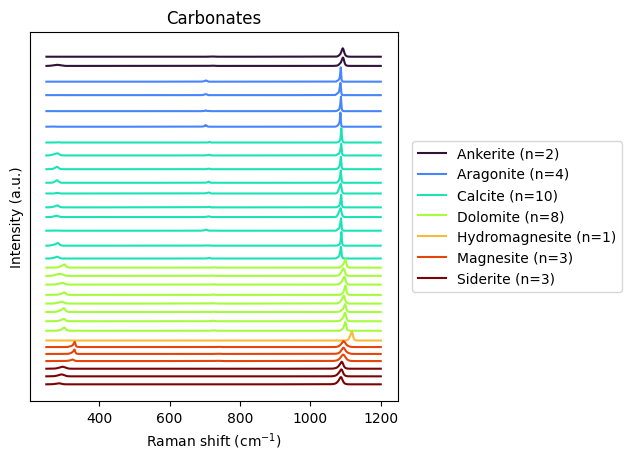

In [39]:
from matplotlib import colormaps

db = local_rruff

search_id = "Magnesite|Hydromagnesite|Siderite|Calcite|Dolomite|Ankerite|Aragonite|Breunnerite"#"CO_3"
search_by = "##NAMES"#"##MEASURED CHEMISTRY"
name_pattern = re.compile(search_id)

title = "Carbonates"
plot_type = "single stacked"

matching_indices = [ i for i, meta in enumerate(db[1]) if name_pattern.search(str(meta.get(search_by, ""))) ]

db_sub = ( [db[0][i] for i in matching_indices], [db[1][i] for i in matching_indices] )
db_sub_pp = ( pipe_selected.apply(db_sub[0]), db_sub[1].copy() )

sorted_pairs = sorted( zip(db_sub_pp[0], db_sub_pp[1]), key=lambda x: x[1].get("##NAMES", "") )
spectra_sorted = [p[0] for p in sorted_pairs]
metadata_sorted = [p[1] for p in sorted_pairs]

unique_names = sorted( set(meta.get("##NAMES", "") for meta in metadata_sorted) )

cmap = colormaps["turbo"]
colour_dict = { mineral: cmap(i / max(len(unique_names) - 1, 1)) for i, mineral in enumerate(unique_names) }
colours = [ colour_dict[meta["##NAMES"]] for meta in metadata_sorted ]
name_counts = {
    name: sum(m["##NAMES"] == name for m in metadata_sorted)
    for name in unique_names
}

labels = [
    f"{meta['##NAMES']} (n={name_counts[meta['##NAMES']]})"
    for meta in metadata_sorted
]
rp.plot.spectra(spectra_sorted, plot_type=plot_type, title=title, color=colours, label=labels)
plt.show()

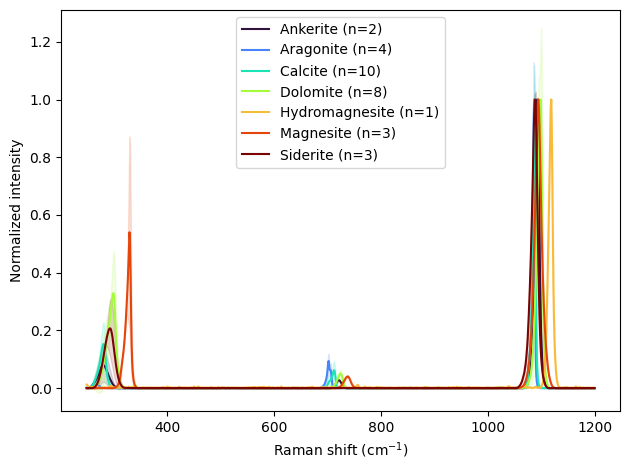

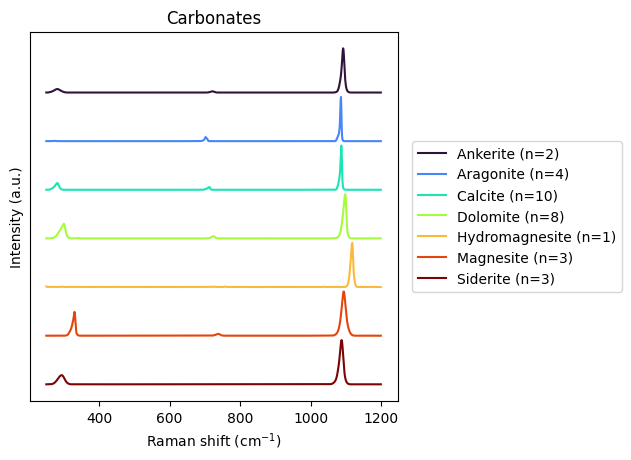

In [6]:
spectra = db_sub_pp[0]
metadata = db_sub_pp[1]

common_axis = np.arange(250, 1200, 1)

mean_library = {}
unique_minerals = sorted( set(meta["##NAMES"] for meta in db_sub_pp[1]) )

for mineral in unique_minerals:
    mineral_spectra = [ spec for spec, meta in zip(db_sub_pp[0],db_sub_pp[1]) if meta["##NAMES"] == mineral ]
    if len(mineral_spectra) == 0:
        continue
    Y = np.vstack([ np.interp( common_axis, s.spectral_axis, s.spectral_data ) for s in mineral_spectra ])

    mean_y = Y.mean(axis=0)
    std_y = Y.std(axis=0)

    scale = mean_y.max()
    mean_y_norm = mean_y / scale
    std_y_norm = std_y / scale

    mean_library[mineral] = { "mean": rp.Spectrum(mean_y_norm, common_axis), "std": std_y_norm, "n": len(mineral_spectra) }
    plt.plot( common_axis, mean_y_norm, color=colour_dict[mineral], linewidth=1.5, label=f"{mineral} (n={len(mineral_spectra)})" )
    plt.fill_between( common_axis, mean_y_norm - std_y_norm, mean_y_norm + std_y_norm, color=colour_dict[mineral], alpha=0.15 )

plt.xlabel("Raman shift (cm$^{-1}$)")
plt.ylabel("Normalized intensity")
plt.legend()
plt.tight_layout()
plt.show()

rp.plot.spectra( [mean_library[m]["mean"] for m in unique_minerals], plot_type=plot_type, title=title, 
color=[colour_dict[m] for m in unique_minerals], label=[ f"{m} (n={mean_library[m]['n']})" for m in unique_minerals ] )
plt.show()

### Optional to see forsterite...

[83,
 141,
 560,
 921,
 1284,
 1648,
 1770,
 1785,
 1919,
 2147,
 2331,
 2356,
 2532,
 2632,
 2835,
 2851,
 2941]

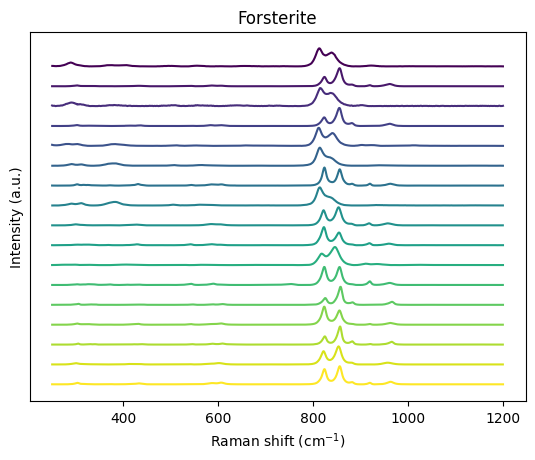

In [ ]:
db=local_rruff

search_id = "Forsterite"#"Mg_2_SiO_4"#"Forsterite"#"Mg_2_SiO_4"
search_by = "##NAMES"#"##IDEAL CHEMISTRY"##"##MEASURED CHEMISTRY"
name_pattern = re.compile(search_id)

title="Forsterite"
plot_type='single stacked'


# Find matching indices
matching_indices = [
    i for i, meta in enumerate(db[1]) 
    if name_pattern.search(meta.get(search_by, ""))
]

# Create sublists
db_sub = (
    [db[0][i] for i in matching_indices],
    [db[1][i] for i in matching_indices] 
)
# Process and plot the spectra
db_sub_pp=(pipe2.apply(db_sub[0]),db_sub[1].copy())

rruff_plot = rp.plot.spectra(db_sub_pp[0], plot_type=plot_type,title=title)
matching_indices

## We can create a mean spectrum for a mineral (e.g. Forsterite)

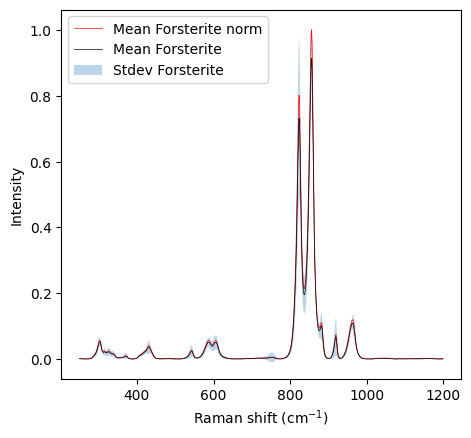

In [8]:
spectra = db_sub_pp[0]
common_axis = np.arange(250, 1200, 1)

Y = np.vstack([np.interp(common_axis, s.spectral_axis, s.spectral_data) for s in spectra])
mean_y = Y.mean(axis=0)
std_y = Y.std(axis=0)

mean_y_norm=mean_y/ mean_y.max()

mean_spectrum = rp.Spectrum(mean_y, common_axis)
mean_spectrum_norm = rp.Spectrum(mean_y_norm, common_axis)

mean_library["Forsterite"] = { "mean": mean_spectrum_norm, "std": std_y / mean_y.max(), "n": len(spectra)}

rp.plot.spectra(mean_spectrum_norm, color='red',linestyle="-",linewidth=0.5,label=f"Mean {title} norm")
rp.plot.spectra(mean_spectrum, title="" ,color='k',linestyle="-",linewidth=0.5,label=f"Mean {title}")
plt.fill_between(common_axis, mean_y - std_y, mean_y + std_y, alpha=0.3, label=f"Stdev {title}")

plt.xlabel('Raman shift (cm$^{-1}$)')
plt.ylabel('Intensity')

plt.legend()
plt.show()

## Now pick you spectrum and clean it up as you want 

<Axes: title={'center': 'Raman spectra'}, xlabel='Raman shift (cm$^{{{-1}}}$)', ylabel='Intensity (a.u.)'>

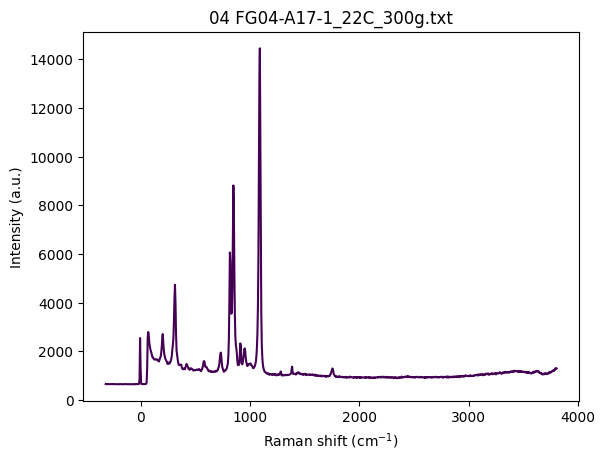

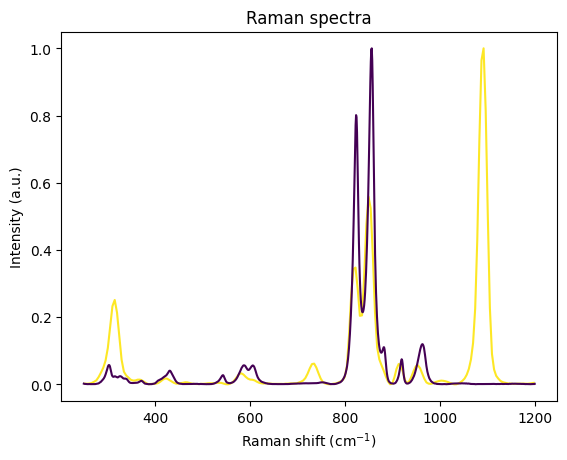

In [9]:
filename="G170_004_2_4_20MW_2400G_45S_5ACC (CRR).txt"

file_path=os.path.join(Master_Folder,"Example_spectra"+slash+"GP_AnnikaDechert"+slash+"spectra_07282025_txt"+slash+filename)

filename='04 FG04-A17-1_22C_300g.txt'
file_path='/Users/cljd/pCloud Drive/PUG/POSTDOC-UCB/BERKELEY-VIBE/Projects/FIcarbonate/Data/CARBEXP_FG04-A17-09112023/Spectra/04 FG04-A17-1_22C_300g.txt'
unknown_spectrum=load_witec_headlesstxt(file_path)

preprocessed_unknown_spectrum = pipe_selected.apply(unknown_spectrum)


unknown_plot = rp.plot.spectra([unknown_spectrum, preprocessed_unknown_spectrum], plot_type='separate',title=filename)
rp.plot.spectra(mean_library["Forsterite"]["mean"])


<Axes: title={'center': '04 FG04-A17-1_22C_300g.txt'}, xlabel='Raman shift (cm$^{{{-1}}}$)', ylabel='Intensity (a.u.)'>

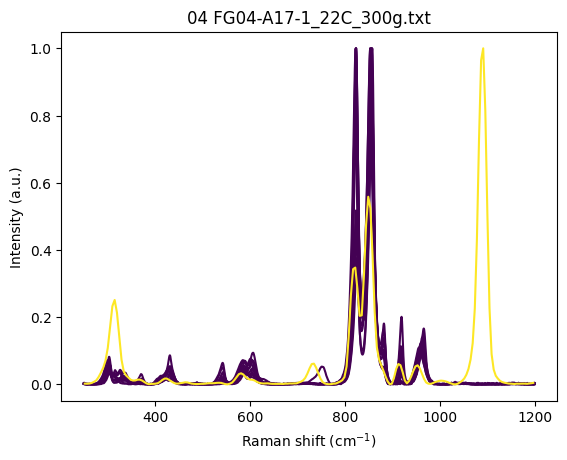

In [11]:
rp.plot.spectra([db_sub_pp[0],preprocessed_unknown_spectrum], plot_type='single',title=filename)

<Axes: title={'center': 'raw spectrum 04 FG04-A17-1_22C_300g.txt'}, xlabel='Raman shift (cm$^{{{-1}}}$)', ylabel='Intensity (a.u.)'>

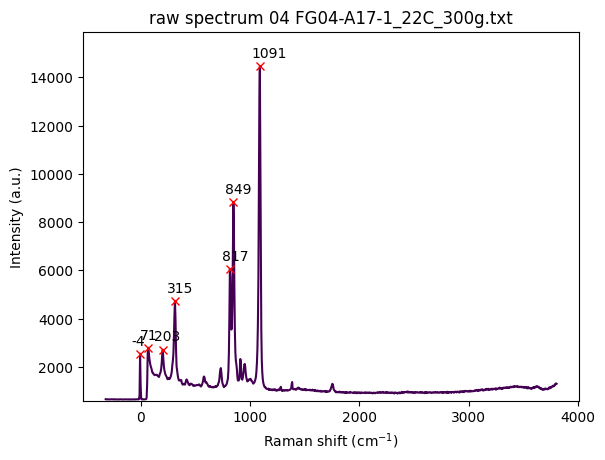

In [12]:
# To show the main peaks in the raw spectrum;  tweak prominence if needed
rp.plot.peaks(unknown_spectrum, plot_type='separate', prominence=1000,title="raw spectrum " + filename)

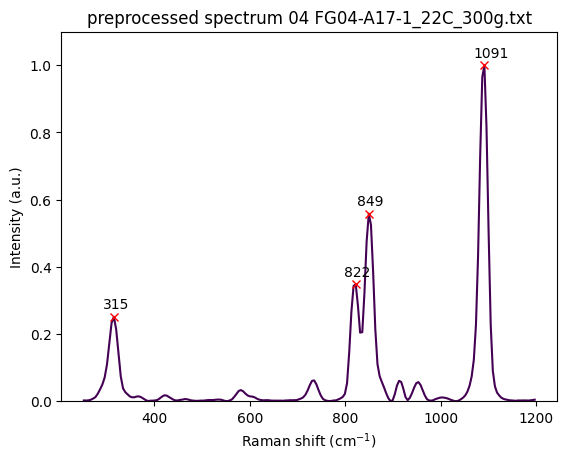

In [13]:
# To show the main peaks in preprocessed spectrum
preprocessed_peaks = rp.plot.peaks(preprocessed_unknown_spectrum, plot_type='separate', prominence=0.07,title="preprocessed spectrum "+filename)

In [14]:
mean_database = (
[v["mean"] for v in mean_library.values()],
[{"##NAMES": k} for k in mean_library.keys()]
)

<Axes: title={'center': 'Top10 matches  vs 04 FG04-A17-1_22C_300g.txt'}, xlabel='Raman shift (cm$^{{{-1}}}$)', ylabel='Intensity (a.u.)'>

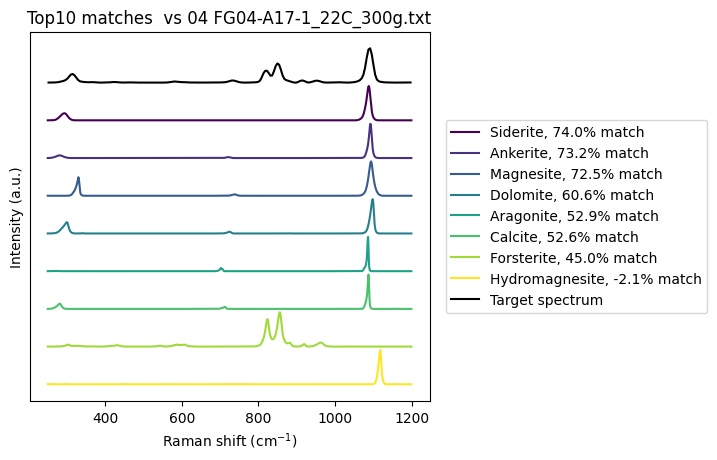

In [15]:
## This calculates the similarity 
database=mean_database#local_rruff_pp
plot_type='single stacked'
target_spectrum=preprocessed_unknown_spectrum

N=10
similarity_scores = []
for index, spectrum in enumerate(database[0]):
    similarity = spectral_similarity(target_spectrum, spectrum)
    similarity_scores.append((index, similarity))

sim1=similarity_scores.copy()
similarity_scores.sort(key=lambda x: x[1], reverse=True)
top_matches = similarity_scores[:N]


rp.plot.spectra([database[0][index] for index,_ in top_matches], 
                label=[database[1][index]['##NAMES']+f", {similarity*100:.1f}% match" for index,similarity in top_matches], 
                plot_type=plot_type)

rp.plot.spectra(target_spectrum, label="Target spectrum", color='k',title=f"Top{N} matches  vs {filename}")


/var/folders/67/plm8qvg12r964t15pv25b7kr0000gn/T/ipykernel_5360/1814100140.py:67: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


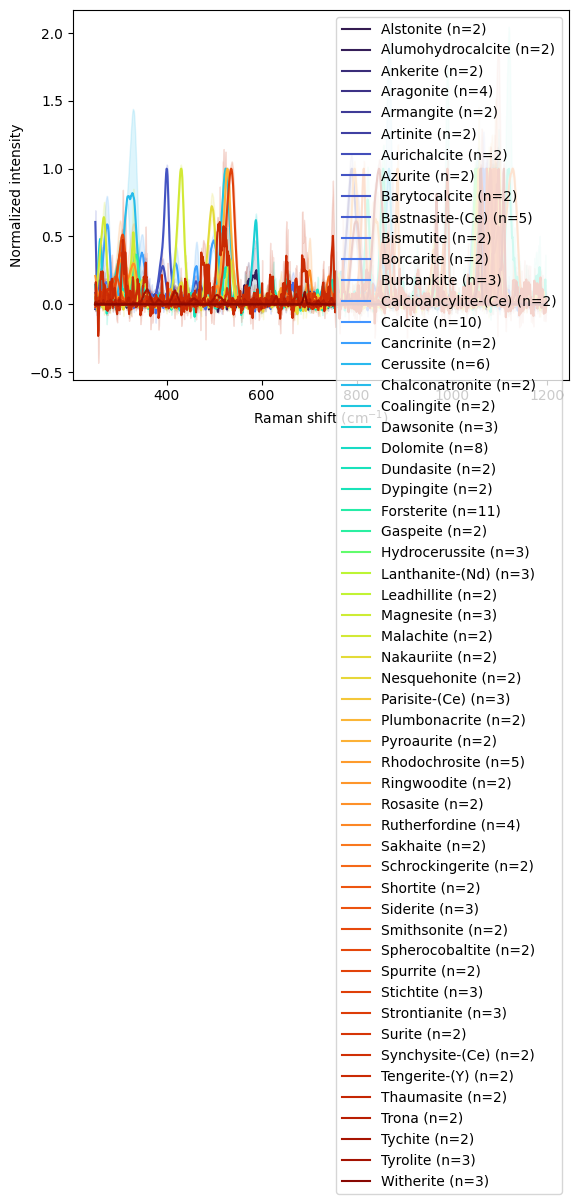

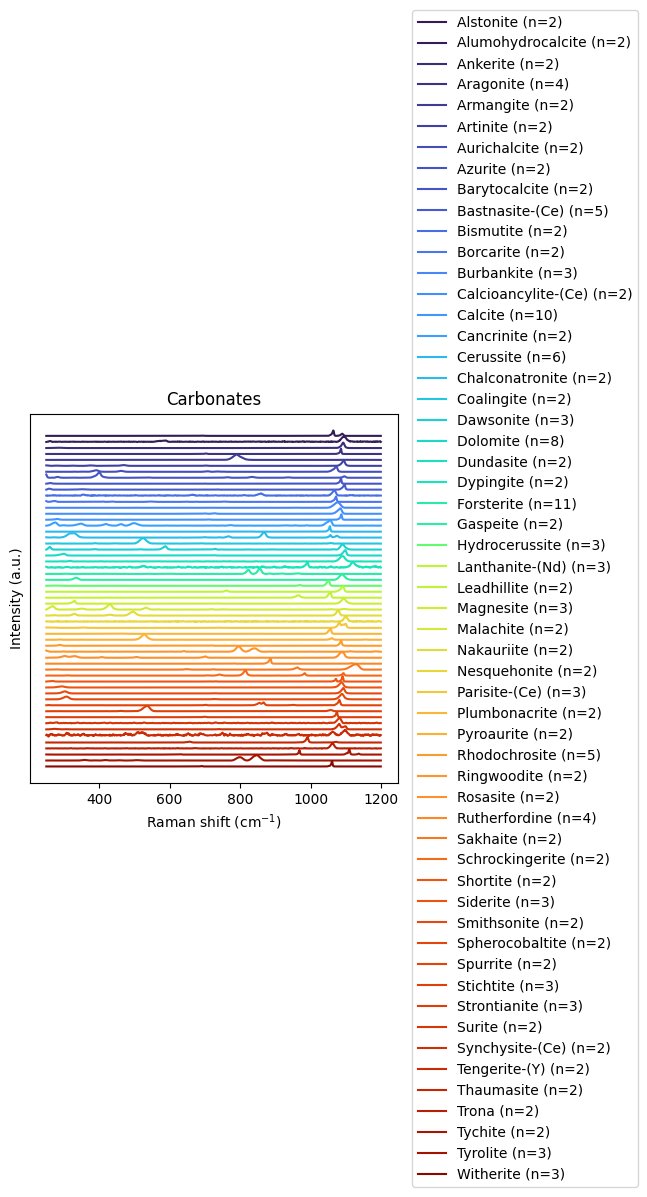

In [36]:
from matplotlib import colormaps

db = local_rruff

search_id = "CO_3|Mg_2_SiO_4|Fe^2+^_2_SiO_4_"#"Magnesite|Hydromagnesite|Siderite|Calcite|Dolomite|Ankerite|Aragonite"
search_by = "##IDEAL CHEMISTRY"#"##NAMES"
name_pattern = re.compile(search_id)

title = "Carbonates"
plot_type = "single stacked"

matching_indices = [ i for i, meta in enumerate(db[1]) if name_pattern.search(str(meta.get(search_by, ""))) ]

db_sub = ( [db[0][i] for i in matching_indices], [db[1][i] for i in matching_indices] )
db_sub_pp = ( pipe_selected.apply(db_sub[0]), db_sub[1].copy() )

sorted_pairs = sorted( zip(db_sub_pp[0], db_sub_pp[1]), key=lambda x: x[1].get("##NAMES", "") )
spectra_sorted = [p[0] for p in sorted_pairs]
metadata_sorted = [p[1] for p in sorted_pairs]

unique_names = sorted( set(meta.get("##NAMES", "") for meta in metadata_sorted) )

cmap = colormaps["turbo"]
colour_dict = { mineral: cmap(i / max(len(unique_names) - 1, 1)) for i, mineral in enumerate(unique_names) }
colours = [ colour_dict[meta["##NAMES"]] for meta in metadata_sorted ]
name_counts = {
    name: sum(m["##NAMES"] == name for m in metadata_sorted)
    for name in unique_names
}

labels = [
    f"{meta['##NAMES']} (n={name_counts[meta['##NAMES']]})"
    for meta in metadata_sorted
]
# rp.plot.spectra(spectra_sorted, plot_type=plot_type, title=title, color=colours, label=labels)
# plt.show()

### Calculate mean spectra
spectra = db_sub_pp[0]
metadata = db_sub_pp[1]

common_axis = np.arange(250, 1200, 1)

mean_library = {}
unique_minerals = sorted( set(meta["##NAMES"] for meta in db_sub_pp[1]) )

for mineral in unique_minerals:
    mineral_spectra = [ spec for spec, meta in zip(db_sub_pp[0],db_sub_pp[1]) if meta["##NAMES"] == mineral ]
    if len(mineral_spectra) < 2:
        continue
    Y = np.vstack([ np.interp( common_axis, s.spectral_axis, s.spectral_data ) for s in mineral_spectra ])

    mean_y = Y.mean(axis=0)
    std_y = Y.std(axis=0)

    scale = mean_y.max()
    mean_y_norm = mean_y / scale
    std_y_norm = std_y / scale

    mean_library[mineral] = { "mean": rp.Spectrum(mean_y_norm, common_axis), "std": std_y_norm, "n": len(mineral_spectra) }
    plt.plot( common_axis, mean_y_norm, color=colour_dict[mineral], linewidth=1.5, label=f"{mineral} (n={len(mineral_spectra)})" )
    plt.fill_between( common_axis, mean_y_norm - std_y_norm, mean_y_norm + std_y_norm, color=colour_dict[mineral], alpha=0.15 )

plt.xlabel("Raman shift (cm$^{-1}$)")
plt.ylabel("Normalized intensity")
plt.legend()
plt.tight_layout()
plt.show()

plot_minerals = list(mean_library.keys())

rp.plot.spectra( [mean_library[m]["mean"] for m in plot_minerals], plot_type=plot_type,
 title=title, color=[colour_dict[m] for m in plot_minerals], label=[ f"{m} (n={mean_library[m]['n']})" for m in plot_minerals ] )
plt.show()


Top pure matches:

Dundasite           82.0%
Gaspeite            77.3%
Spherocobaltite     75.7%
Rosasite            75.7%
Siderite            74.0%
Lanthanite-(Nd)     73.6%
Ankerite            73.5%
Parisite-(Ce)       73.5%
Smithsonite         73.4%
Magnesite           72.7%
Artinite            70.9%
Alumohydrocalcite   70.9%
Synchysite-(Ce)     67.7%
Dawsonite           63.6%
Dolomite            59.4%
Bastnasite-(Ce)     59.1%
Calcioancylite-(Ce) 57.9%
Rhodochrosite       57.1%
Shortite            55.8%
Barytocalcite       52.8%
Aragonite           52.7%
Calcite             52.3%
Spurrite            50.7%
Surite              44.4%
Nesquehonite        43.1%
Forsterite          41.6%
Burbankite          37.6%
Schrockingerite     36.6%
Tengerite-(Y)       34.6%
Tyrolite            34.6%
Alstonite           25.8%
Nakauriite          17.1%
Ringwoodite         16.7%
Chalconatronite     15.7%
Bismutite           14.5%
Strontianite        9.5%
Azurite             8.6%
Aurichalcite        

<Axes: title={'center': 'Top mixture models vs 04 FG04-A17-1_22C_300g.txt'}, xlabel='Raman shift (cm$^{{{-1}}}$)', ylabel='Intensity (a.u.)'>

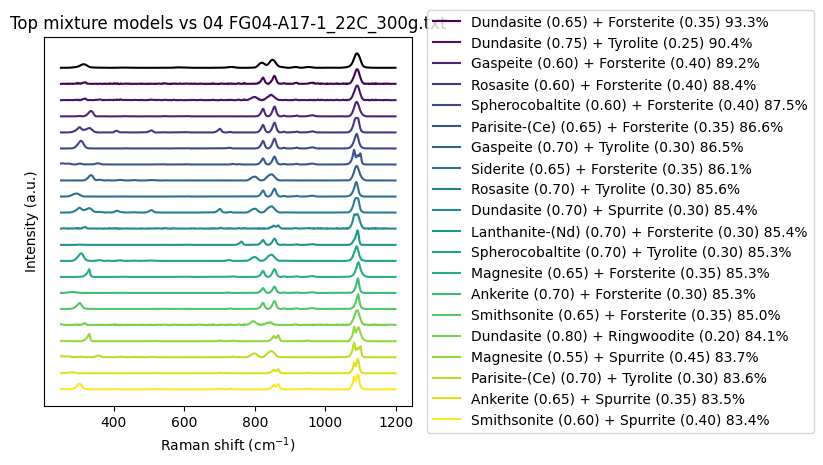

In [41]:
from itertools import combinations
import numpy as np
import ramanspy as rp

# --------------------------------------------------
# INPUTS
# --------------------------------------------------

mean_database = (
[v["mean"] for v in mean_library.values()],
[{"##NAMES": k} for k in mean_library.keys()]
)
database = mean_database
target_spectrum = preprocessed_unknown_spectrum

plot_type = "single stacked"

N_candidates = 200
N_models = 20

weights = np.linspace(
    0.05,
    0.95,
    19
)

# minimum improvement over BEST pure match overall
MIN_ABSOLUTE_IMPROVEMENT = 0.0   # 5 percentage points

# --------------------------------------------------
# PURE SEARCH
# --------------------------------------------------

similarity_scores = []

for index, spectrum in enumerate(database[0]):

    sim = spectral_similarity(
        target_spectrum,
        spectrum
    )

    similarity_scores.append(
        (index, sim)
    )

similarity_scores.sort(
    key=lambda x: x[1],
    reverse=True
)

candidate_indices = [
    idx
    for idx, _
    in similarity_scores[:N_candidates]
]

print("\nTop pure matches:\n")

for idx, sim in similarity_scores[:N_candidates]:

    print(
        f"{database[1][idx]['##NAMES']:20s}"
        f"{sim*100:.1f}%"
    )

# --------------------------------------------------
# BEST PURE MATCH OVERALL
# --------------------------------------------------

best_pure_score = similarity_scores[0][1]

# --------------------------------------------------
# COMMON AXIS
# --------------------------------------------------

common_axis = np.arange(250,1200,1)

target_y = np.interp(
    common_axis,
    target_spectrum.spectral_axis,
    target_spectrum.spectral_data
)

target_spec_interp = rp.Spectrum(
    target_y,
    common_axis
)

# --------------------------------------------------
# INTERPOLATE CANDIDATES ONCE
# --------------------------------------------------

candidate_vectors = {}

for idx in candidate_indices:

    spec = database[0][idx]

    y = np.interp(
        common_axis,
        spec.spectral_axis,
        spec.spectral_data
    )

    if np.max(y) > 0:
        y = y / np.max(y)

    candidate_vectors[idx] = y

# --------------------------------------------------
# SEARCH ALL PAIRS
# --------------------------------------------------

results = []

for idx1, idx2 in combinations(
    candidate_indices,
    2
):

    y1 = candidate_vectors[idx1]
    y2 = candidate_vectors[idx2]

    best_score = -np.inf
    best_weight = None
    best_spec = None

    for w in weights:

        mix = (
            w * y1 +
            (1-w) * y2
        )

        mix /= mix.max()

        mix_spec = rp.Spectrum(
            mix,
            common_axis
        )

        score = spectral_similarity(
            target_spec_interp,
            mix_spec
        )

        if score > best_score:

            best_score = score
            best_weight = w
            best_spec = mix_spec


    improvement = (
        best_score - best_pure_score
    )

    # Throw away mixtures that don't actually improve
    # over the best pure mineral
    if improvement < MIN_ABSOLUTE_IMPROVEMENT:
        continue

    results.append(
        (
            best_score,
            improvement,
            idx1,
            idx2,
            best_weight,
            best_spec
        )
    )

results.sort(
    key=lambda x: x[0],
    reverse=True
)

top_models = results[:N_models]

rp.plot.spectra(
    [spec for _,_,_,_,_,spec in top_models],
    plot_type=plot_type,
    label=[
        (
            f"{database[1][idx1]['##NAMES']} ({w:.2f}) + "
            f"{database[1][idx2]['##NAMES']} ({1-w:.2f}) "
            f"{score*100:.1f}%"
        )
        for score, improvement, idx1, idx2, w, spec
        in top_models
    ]
)

rp.plot.spectra(
    target_spec_interp,
    color="k",
    title=f"Top mixture models vs {filename}"
)


<Axes: title={'center': 'Magnesio-fluoro-hastingsite vs 6 SK-B-C11.txt'}, xlabel='Raman shift (cm$^{{{-1}}}$)', ylabel='Intensity (a.u.)'>

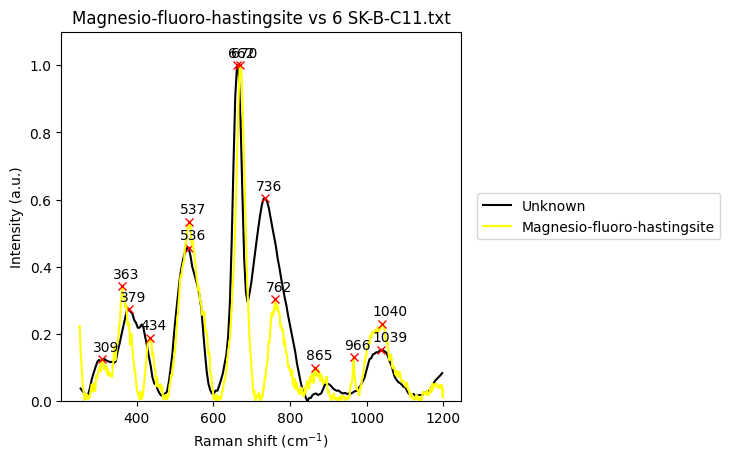

In [80]:
match_2_plot=2
rp.plot.peaks(preprocessed_unknown_spectrum,prominence=0.05,label='Unknown',color='k')
rp.plot.peaks(database[0][top_matches[match_2_plot][0]],prominence=0.05,label=database[1][top_matches[match_2_plot][0]]['##NAMES'],color='yellow',title=f"{database[1][top_matches[match_2_plot][0]]['##NAMES']} vs {filename}")

## If you want to plot a specific mineral against your spectrum 
- you will have to find the correct index in database (for example using the optional parts above and printing variable matching_indices)


In [81]:
matching_indices

[141, 921, 1770, 1919, 2147, 2356, 2532, 2632, 2835, 2851, 2941]

<Axes: title={'center': 'Forsterite vs 6 SK-B-C11.txt'}, xlabel='Raman shift (cm$^{{{-1}}}$)', ylabel='Intensity (a.u.)'>

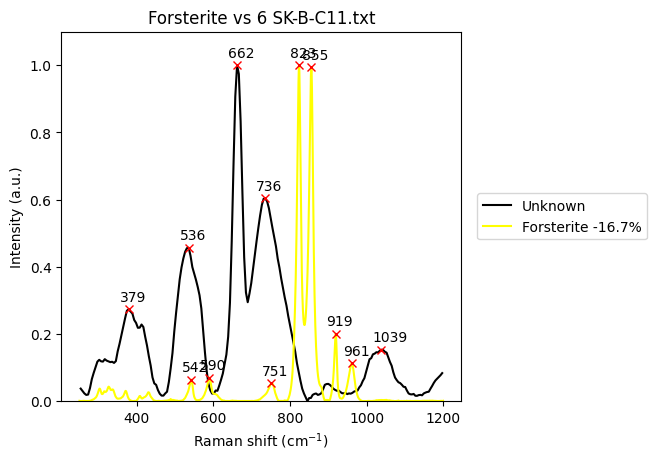

In [ ]:
reference_index=2356

rp.plot.peaks(preprocessed_unknown_spectrum,prominence=0.05,label='Unknown',color='k')
rp.plot.peaks(database[0][reference_index],prominence=0.05,label=f"{database[1][reference_index]['##NAMES']} {sim1[reference_index][1]*100:.1f}%",
              color='yellow',title=f"{database[1][reference_index]['##NAMES']} vs {filename}")

In [66]:
database[1]

[{'##NAMES': 'Hydroxykenomicrolite',
  '##RRUFFID': 'R061058',
  '##IDEAL CHEMISTRY': '([box],Na,Sb^3+^)_2_Ta^5+^_2_O_6_(OH)',
  '##LOCALITY': "Mt. Vasin-Myl'k, Voron'ya Tundra, Russia",
  '##OWNER': 'RRUFF',
  '##SOURCE': 'Michael Scott',
  '##DESCRIPTION': 'Grayish adamantine grains (orange under long wave ultraviolet light) intimately associated with simpsonite (bluish white in SW UV).',
  '##STATUS': 'The identification of this mineral has been confirmed by single-crystal X-ray diffraction.',
  '##URL': 'rruff.info/R061058',
  '##END': ''},
 {'##NAMES': 'Stewartite',
  '##RRUFFID': 'R070643',
  '##IDEAL CHEMISTRY': 'Mn^2+^Fe^3+^_2_(PO_4_)_2_(OH)_2_&#183;8H_2_O',
  '##LOCALITY': 'Hagendorf, Bavaria, Germany',
  '##OWNER': 'RRUFF',
  '##SOURCE': 'Michael Scott',
  '##DESCRIPTION': 'Transparent yellow bladed crystals with orange laueite',
  '##STATUS': 'The identification of this mineral has been confirmed by single-crystal X-ray diffraction.',
  '##URL': 'rruff.info/R070643',
  '##EN